In [1]:
import keras # getestet mit Version 3.4.1
print(keras.__version__)
from keras import layers
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

3.4.1


In [2]:
input_img = keras.Input(shape=(784,)) # 28*28 Pixel = 784 Eingangsdimensionen
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)
latent = layers.Dense(16,activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(latent)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

In [3]:
# Dieses Modell bildet eine Eingabe auf seine Rekonstruktion ab
autoencoder = keras.Model(input_img, decoded)

In [4]:
# Dieses Modell bildet eine Eingabe auf ihre kodierte Darstellung ab
encoder = keras.Model(input_img, latent)

In [5]:
# Die kodierte Eingabe kommt aus dem latenten Raum
encoded_input = keras.Input(shape=(16,)) 
# Abrufen der letzten Schicht des Autoencoder-Modells
decoder_layer = autoencoder.layers[-3]
# Erstellen vom Decoder-Model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
# Daten laden und aufbereiten
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [8]:
# Trainieren des Autoencoders durch Abbilden der Eingabedaten (x_train) auf sich selbst, 
# da das Ziel des Autoencoders die Rekonstruktion der Eingabedaten ist.
# 20 Epochen, Batch-Größe von 256, die Daten nach jeder Epoche mischen (shuffle).
# x_test ist der Validierungsdatensatz zur Bewertung der Leistung während des Trainings.
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.3489 - val_loss: 0.1876
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1761 - val_loss: 0.1515
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1481 - val_loss: 0.1351
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1341 - val_loss: 0.1282
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1281 - val_loss: 0.1239
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1245 - val_loss: 0.1215
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1216 - val_loss: 0.1183
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1190 - val_loss: 0.1170
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1174 - val_loss: 0.1151
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1159 - val_loss: 0.1140
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1146 - val_loss: 0.1128
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [9]:
# Kodierung und Dekodierung von Ziffern aus x_test
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Figure size 640x480 with 0 Axes>

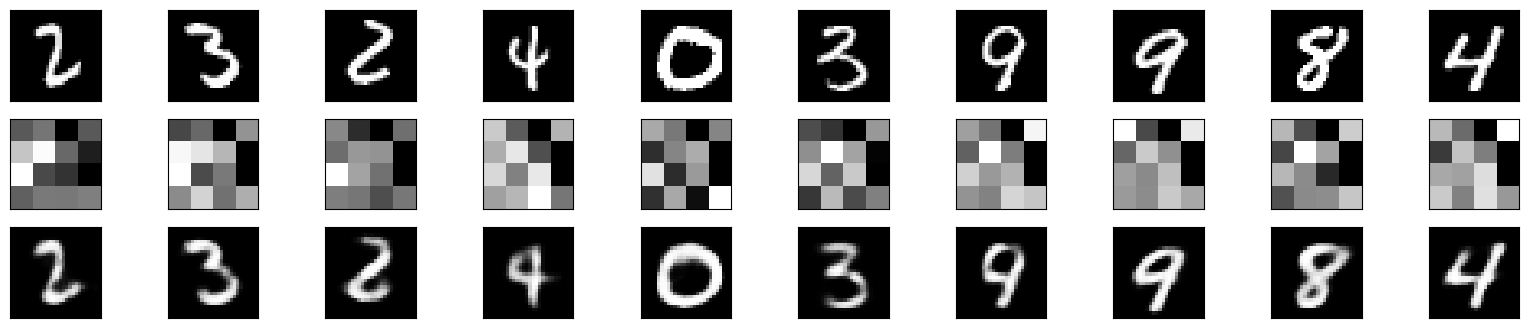

In [10]:
n = 10  # Wie viele Ziffer werden dargestellt
total_images = x_test.shape[0]  # Gesamtzahl der Bilder im Test-Datensatz
mid_index = total_images // 2  # Finden Sie den Mittelpunkt des Test-Datensatzes
#mid_index = 1000 # Oder direkt den gewünschen Bereich angeben

# Start- und Endindex für den Bereich definieren, der um die Mitte zentriert ist
start_index = max(mid_index - n // 2, 0)  # Stellen Sie sicher, dass der Startindex nicht negativ ist
end_index = min(start_index + n, total_images)  # Stellen Sie sicher, dass der Endindex nicht über die Anzahl der Bilder hinausgeht

plt.gray()
encoded_imgs = encoder.predict(x_test)

plt.figure(figsize=(20, 4))
for i in range(start_index, end_index):
    # Berechnen Sie den Index für die Unterplots
    subplot_index = i - start_index + 1
    
    # Anzeigen vom Original
    ax = plt.subplot(3, n, subplot_index)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Lantenten Raum visualisieren
    ax = plt.subplot(3, n, subplot_index + n)
    plt.imshow(encoded_imgs[i].reshape((4, 4)).T)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Anzeigen die Rekonstruktion
    ax = plt.subplot(3, n, subplot_index + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

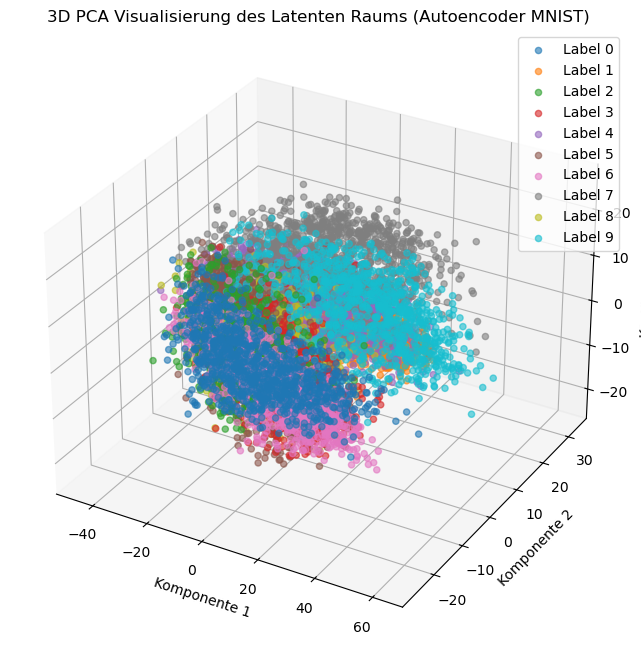

In [24]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Anwenden von PCA, um den latenten Raum auf 3 Dimensionen zu reduzieren
pca = PCA(n_components=3)
latent_3d = pca.fit_transform(encoded_imgs)

# Erstellen einer Farbpalette basierend auf den Labels
unique_labels = np.unique(y_test)
colors = plt.colormaps['tab10']  # 10 Farben für die 10 Ziffern

# 3D-Visualisierung mit farblicher Zuordnuencoded_imgsng der Labels
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Punkte plotten und Farben basierend auf den Labels zuordnen
for i, label in enumerate(unique_labels):
    ax.scatter(latent_3d[y_test == label, 0], latent_3d[y_test == label, 1], latent_3d[y_test == label, 2], 
               color=colors(i), label=f'Label {label}', alpha=0.6)

# Achsenbeschriftung und Titel
ax.set_title('3D PCA Visualisierung des Latenten Raums (Autoencoder MNIST)')
ax.set_xlabel('Komponente 1')
ax.set_ylabel('Komponente 2')
ax.set_zlabel('Komponente 3')

# Legende anzeigen
ax.legend(loc='best')

plt.show()